In [55]:
import pandas as pd

In [56]:
# load excel dataset
data = pd.read_excel('Data/UNHCR_Flow_Data.xlsx', sheet_name='DATA')

# filter out rows where 'Count' is less than 100
data = data[data['Count'] >= 100].copy()
print("number of rows after filtering:", data.shape[0])

number of rows after filtering: 30440


In [57]:
# adjustable rolling window length (years)
window_size = 3

# aggregate to yearly totals for each origin-asylum pair
pair_yearly = (
    data.groupby(['origin', 'OriginName', 'asylum', 'AsylumName', 'Year'], as_index=False)['Count']
    .sum()
)

# compute rolling windows using continuous calendar years
window_rows = []
for (origin, origin_name, asylum, asylum_name), group in pair_yearly.groupby(['origin', 'OriginName', 'asylum', 'AsylumName']):
    yearly = group.set_index('Year')['Count'].sort_index()
    full_years = range(int(yearly.index.min()), int(yearly.index.max()) + 1)
    yearly = yearly.reindex(full_years, fill_value=0)

    rolling_window = yearly.rolling(window=window_size).sum().dropna()
    for end_year, total in rolling_window.items():
        window_rows.append({
            'origin': origin,
            'OriginName': origin_name,
            'asylum': asylum,
            'AsylumName': asylum_name,
            'start_year': int(end_year) - (window_size - 1),
            'end_year': int(end_year),
            'cumulative_count': float(total),
        })

windows = pd.DataFrame(window_rows)
top_window_per_pair = windows.loc[windows.groupby(['origin', 'asylum'])['cumulative_count'].idxmax()]
top_window_per_pair = top_window_per_pair.sort_values('cumulative_count', ascending=False).reset_index(drop=True)

top_window_per_pair.head(20)

,origin,OriginName,asylum,AsylumName,start_year,end_year,cumulative_count
0,AFG,Afghanistan,PAK,Pakistan,1980,1982,2475440.0
1,SYR,Syrian Arab Rep.,TUR,Türkiye,2013,2015,2437742.0
2,ETH,Ethiopia,SOM,Somalia,1978,1980,1977290.0
3,VEN,Venezuela (Bolivarian Republic of),COL,Colombia,2018,2020,1810339.0
4,AFG,Afghanistan,IRN,Iran (Islamic Rep. of),1980,1982,1670000.0
5,IRQ,Iraq,IRN,Iran (Islamic Rep. of),1989,1991,1432000.0
6,RWA,Rwanda,COD,Dem. Rep. of the Congo,1994,1996,1417138.0
7,UKR,Ukraine,GFR,Germany,2022,2024,1373752.0
8,UKR,Ukraine,POL,Poland,2022,2024,1359992.0
9,UKR,Ukraine,RUS,Russian Federation,2022,2024,1322740.0


In [58]:
import numpy as np

# episode-based conflict significance analysis (variable-length conflicts)
min_activation = 10000         # minimum yearly displaced people to consider a year "active"
max_activation = 100000        # maximum threshold to handle anomalies like Afghanistan
activation_multiplier = 1.0     # origin-specific threshold = baseline * multiplier
quiet_years_to_end = 1          # end episode after this many consecutive below-threshold years

# aggregate to origin-year totals (sum across all asylum countries)
origin_yearly = (
    data.groupby(['origin', 'OriginName', 'Year'], as_index=False)['Count']
    .sum()
)

def detect_origin_episodes(group):
    series = group.set_index('Year')['Count'].sort_index()
    full_years = range(int(series.index.min()), int(series.index.max()) + 1)
    series = series.reindex(full_years, fill_value=0)

    positive = series[series > 0]
    baseline = float(positive.median()) if not positive.empty else 0.0
    threshold = min( max(min_activation, baseline * activation_multiplier), max_activation)

    episodes = []
    in_episode = False
    start_year = None
    low_streak = 0

    for year, value in series.items():
        if not in_episode and value >= threshold:
            in_episode = True
            start_year = int(year)
            low_streak = 0
            continue

        if in_episode:
            if value < threshold:
                low_streak += 1
                if low_streak >= quiet_years_to_end:
                    end_year = int(year) - quiet_years_to_end
                    if end_year >= start_year:
                        episodes.append((start_year, end_year, threshold))
                    in_episode = False
                    start_year = None
                    low_streak = 0
            else:
                low_streak = 0

    if in_episode and start_year is not None:
        episodes.append((start_year, int(series.index.max()), threshold))

    rows = []
    for episode_num, (start, end, threshold_used) in enumerate(episodes, start=1):
        episode_series = series.loc[start:end]
        total_displaced = float(episode_series.sum())
        peak_annual = float(episode_series.max())
        duration_years = int(end - start + 1)
        mean_annual = float(total_displaced / duration_years)
        ramp_up = float(episode_series.diff().fillna(0).max())

        rows.append({
            'origin': group['origin'].iloc[0],
            'OriginName': group['OriginName'].iloc[0],
            'episode': episode_num,
            'start_year': start,
            'end_year': end,
            'duration_years': duration_years,
            'threshold_used': float(threshold_used),
            'total_displaced': total_displaced,
            'peak_annual': peak_annual,
            'mean_annual': mean_annual,
            'ramp_up': ramp_up,
        })

    return rows

episode_rows = []
for _, g in origin_yearly.groupby(['origin', 'OriginName']):
    episode_rows.extend(detect_origin_episodes(g))

episodes_df = pd.DataFrame(episode_rows)

top_by_total = episodes_df.sort_values('total_displaced', ascending=False).reset_index(drop=True).head(20)
top_by_peak = episodes_df.sort_values('peak_annual', ascending=False).reset_index(drop=True).head(20)

print('Top episodes by total displaced:')
display(top_by_total)
print('Top episodes by peak annual displaced:')
display(top_by_peak)

Top episodes by total displaced:


,origin,OriginName,episode,start_year,end_year,duration_years,threshold_used,total_displaced,peak_annual,mean_annual,ramp_up
0,SYR,Syrian Arab Rep.,1,2011,2025,15,10000.0,9517110.0,2264590.0,6.344740e+05,1585679.0
1,VEN,Venezuela (Bolivarian Republic of),1,2015,2025,11,10000.0,8578012.0,2528237.0,7.798193e+05,2402156.0
2,UKR,Ukraine,3,2022,2025,4,10000.0,8125528.0,5781363.0,2.031382e+06,0.0
3,AFG,Afghanistan,3,1999,2024,26,100000.0,6651970.0,916238.0,2.558450e+05,741438.0
4,AFG,Afghanistan,1,1980,1988,9,100000.0,5765023.0,2354302.0,6.405581e+05,1046116.0
5,SSD,South Sudan,1,2014,2018,5,100000.0,2599066.0,1005508.0,5.198132e+05,575524.0
6,SUD,Sudan,7,2022,2025,4,33995.5,2451873.0,1069442.0,6.129682e+05,753164.0
7,RWA,Rwanda,6,1994,1996,3,10000.0,2434129.0,2310857.0,8.113763e+05,52272.0
8,ETH,Ethiopia,3,1977,1980,4,24395.0,2289490.0,1571784.0,5.723725e+05,1135473.0
9,SRB,Serbia and Kosovo: S/RES/1244 (1999),1,1988,2006,19,16186.5,2115723.0,990211.0,1.113538e+05,858950.0


Top episodes by peak annual displaced:


,origin,OriginName,episode,start_year,end_year,duration_years,threshold_used,total_displaced,peak_annual,mean_annual,ramp_up
0,UKR,Ukraine,3,2022,2025,4,10000.0,8125528.0,5781363.0,2.031382e+06,0.0
1,VEN,Venezuela (Bolivarian Republic of),1,2015,2025,11,10000.0,8578012.0,2528237.0,7.798193e+05,2402156.0
2,AFG,Afghanistan,1,1980,1988,9,100000.0,5765023.0,2354302.0,6.405581e+05,1046116.0
3,RWA,Rwanda,6,1994,1996,3,10000.0,2434129.0,2310857.0,8.113763e+05,52272.0
4,SYR,Syrian Arab Rep.,1,2011,2025,15,10000.0,9517110.0,2264590.0,6.344740e+05,1585679.0
5,ETH,Ethiopia,3,1977,1980,4,24395.0,2289490.0,1571784.0,5.723725e+05,1135473.0
6,IRQ,Iraq,2,1991,1991,1,31772.0,1422637.0,1422637.0,1.422637e+06,0.0
7,SUD,Sudan,7,2022,2025,4,33995.5,2451873.0,1069442.0,6.129682e+05,753164.0
8,SSD,South Sudan,1,2014,2018,5,100000.0,2599066.0,1005508.0,5.198132e+05,575524.0
9,SRB,Serbia and Kosovo: S/RES/1244 (1999),1,1988,2006,19,16186.5,2115723.0,990211.0,1.113538e+05,858950.0


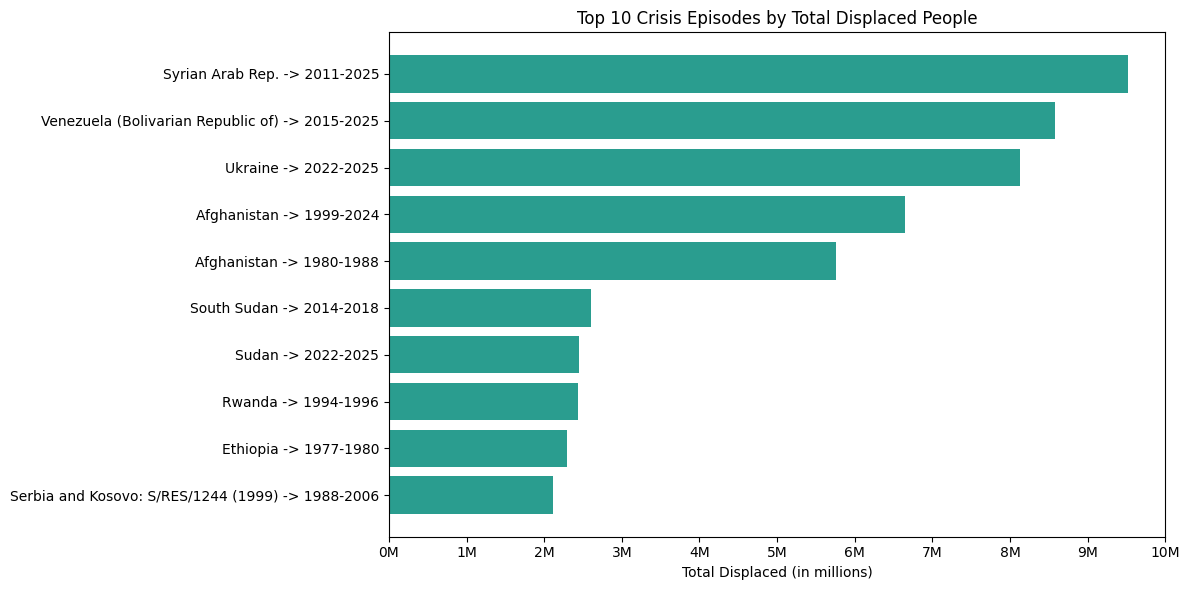

In [60]:
import matplotlib.pyplot as plt

# horizontal bar chart for the top 10 episodes by composite score
if episodes_df.empty:
    print('No episodes were detected with the current thresholds.')
else:
    chart_data = top_by_total.head(10).copy().sort_values('total_displaced', ascending=True)
    chart_data['episode_label'] = (
        chart_data['OriginName'] + ' -> ' + chart_data['start_year'].astype(str) + '-' + chart_data['end_year'].astype(str)
    )

    plt.figure(figsize=(12, 6))
    plt.barh(chart_data['episode_label'], chart_data['total_displaced'], color='#2a9d8f')
    plt.xlabel('Total Displaced (in millions)')
    # x-axis ticks every 1 million
    plt.xticks(
        np.arange(0, 10000001, 1000000),
        [f'{i}M' for i in range(11)]
    )
    plt.title('Top 10 Crisis Episodes by Total Displaced People')
    plt.tight_layout()
    plt.savefig('Graphs and visualizations/top_10_displacement_episodes.svg', format='svg')
    plt.show()